In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

data = pd.read_csv('Numerical-ChordwiseAddress.csv', sep=';', header=None, dtype=float)

chord_pos = np.array(data)

chord_pos = chord_pos.flatten()

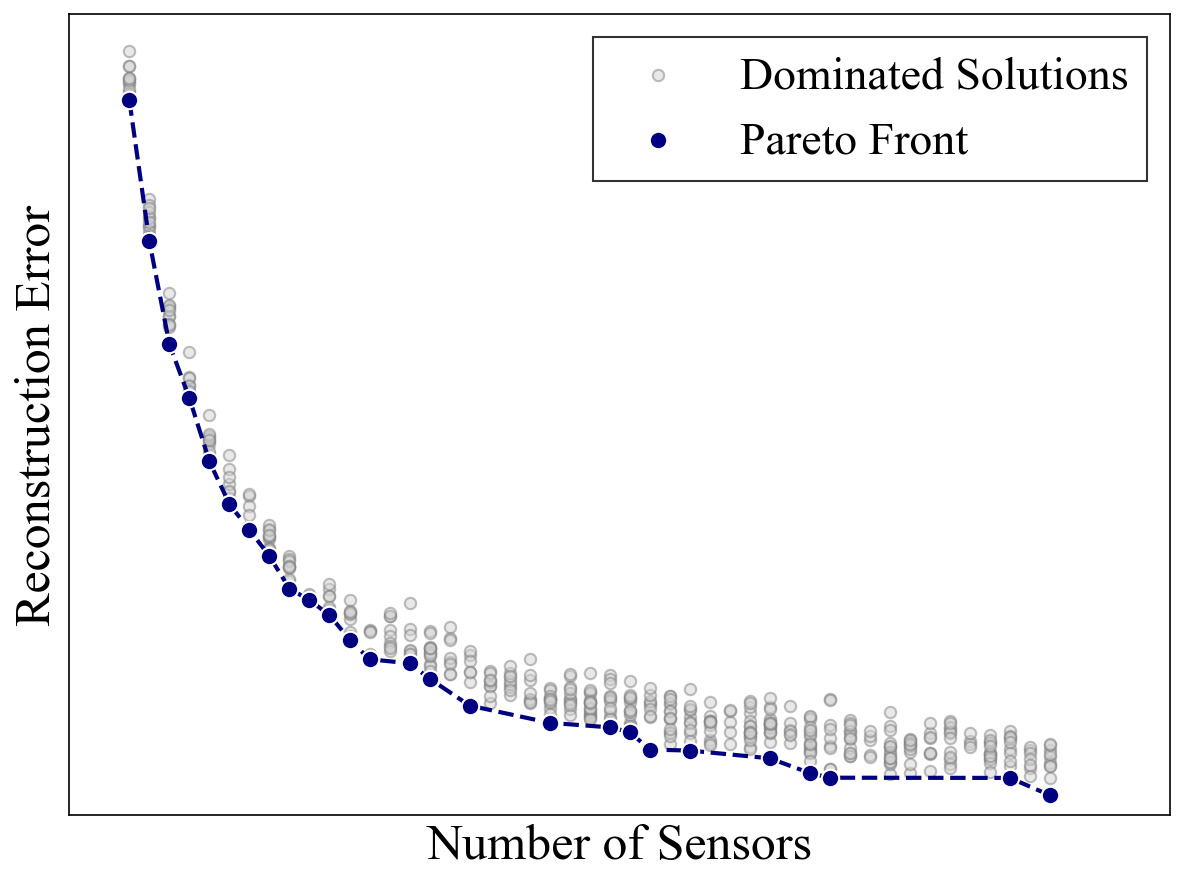

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def identify_pareto(scores):
    """
    Filtra a Frente de Pareto a partir de um conjunto de custos (Minimização).
    """
    population_size = scores.shape[0]
    population_ids = np.arange(population_size)
    pareto_front = np.ones(population_size, dtype=bool)
    
    for i in range(population_size):
        for j in range(population_size):
            if i == j: continue
            if all(scores[j] <= scores[i]) and any(scores[j] < scores[i]):
                pareto_front[i] = 0
                break
    return population_ids[pareto_front]

# --- 1. Geração de Dados (Igual ao anterior) ---
np.random.seed(42)
num_points = 500
f2_sensors = np.random.randint(3, 50, num_points)
f1_error = (100 / (f2_sensors + 1)) + np.random.normal(0, 0.5, num_points)
f1_error = np.abs(f1_error)
data = np.vstack((f1_error, f2_sensors)).T

# --- 2. Calcular Pareto ---
pareto_indices = identify_pareto(data)
pareto_data = data[pareto_indices]
pareto_data = pareto_data[pareto_data[:, 1].argsort()]

# --- 3. Plotagem Ajustada ---
plt.figure(figsize=(8, 6), dpi=150)

# Soluções Dominadas (Cinza)
plt.scatter(data[:, 1], data[:, 0], 
            c='lightgray', edgecolors='grey', s=30, alpha=0.5, 
            label='Dominated Solutions')

# Frente de Pareto (Agora em AZUL MARINHO)
plt.plot(pareto_data[:, 1], pareto_data[:, 0], 
         c='navy', linestyle='--', linewidth=2, zorder=5) # Linha
plt.scatter(pareto_data[:, 1], pareto_data[:, 0], 
            c='navy', s=70, edgecolors='white', zorder=10, # Pontos
            label='Pareto Front')

# --- 4. Estilização ---
plt.xlabel('Number of Sensors', fontsize=24, fontname='Times New Roman')
plt.ylabel('Reconstruction Error', fontsize=24, fontname='Times New Roman')

plt.grid(True, linestyle='--', alpha=0.4)
font_properties = {'family': 'Times New Roman', 'weight': 'normal', 'size': 22} # Ex: 'serif' imita Times New Roman
plt.legend(fontsize=22, frameon=True, fancybox=False, edgecolor='black', prop=font_properties)

# REMOVER OS VALORES DOS EIXOS (Labels)
plt.xticks([])  # Remove números do eixo X
plt.yticks([])  # Remove números do eixo Y

# Ajuste de limites para não cortar as bolinhas
plt.xlim(0, 55)
plt.ylim(bottom=0)

plt.tight_layout()
plt.savefig('teste.png', dpi=600)
plt.show()

In [108]:
data = pd.read_csv('Numerical-PressureDistributionData.csv', sep=',')

cl_data = data.iloc[20721,3]
cp_data = data.iloc[20721,4:]

cp_data = np.array(cp_data)

In [90]:
data = pd.read_csv('test_cp.csv', sep=';', header=None)

cp_data = data.iloc[:,2]

cp_data = cp_data.iloc[::2].reset_index(drop=True)

cp_data = np.array(cp_data)

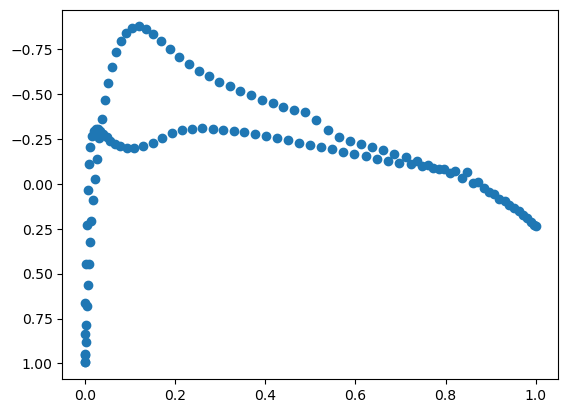

In [109]:
plt.scatter(chord_pos, cp_data)
plt.gca().invert_yaxis()
plt.show()

In [111]:
print(np.trapz(cp_data, chord_pos))
print(cl_data)

0.16589268705
0.1666


In [114]:
x_tensor = chord_pos
(x_tensor[1:] - x_tensor[:-1]).shape

(119,)

In [ ]:
def tf_trapz(y_pred, x_tensor):
    dx = x_tensor[1:] - x_tensor[:-1]
    y_avg = (y_pred[:, 1:] + y_pred[:,:-1]) / 2
    integral = tf.reduce_sum(y_avg * dx, axis=1)